# Proyecto: Clasificador de Letras ASL

Se seleccionó una submuestra del dataset original de Kaggle para este laboratorio. Tomé 600 imágenes por cada clase, lo cual es suficiente para capturar la variabilidad de los datos sin sobrepasar las limitaciones de cómputo y tiempo del entorno de trabajo.

## Ejemplos de imágenes

A continuación muestro ejemplos de cinco letras distintas del alfabeto ASL para observar la variabilidad de las imágenes dentro de una misma clase.

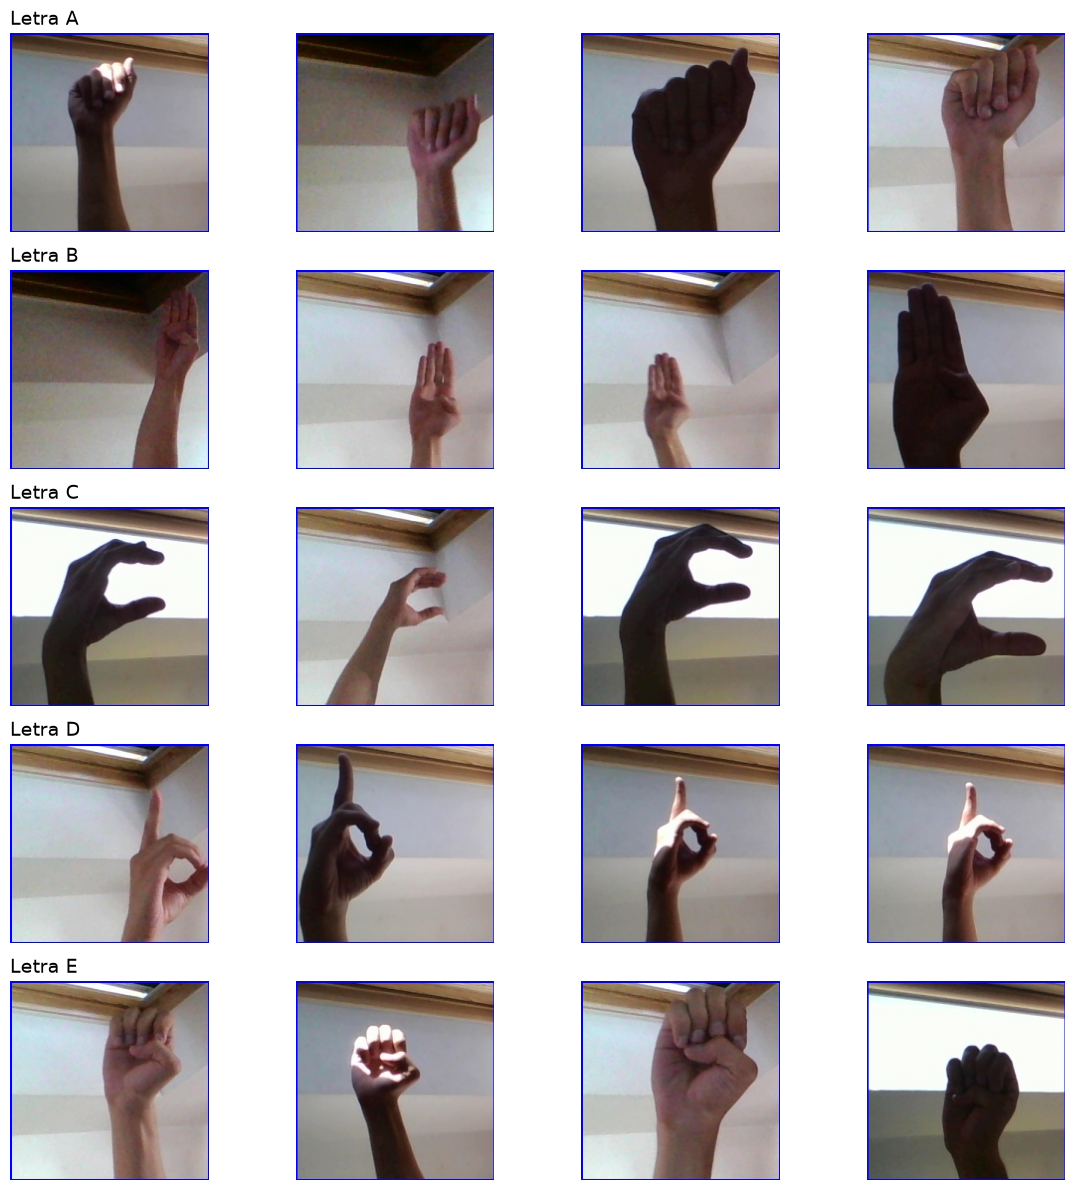

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

letras = ['A', 'B', 'C', 'D', 'E']
muestras_por_letra = 4
base_path = '../data'

fig, axes = plt.subplots(len(letras), muestras_por_letra, figsize=(12, 12))

for i, letra in enumerate(letras):
    letra_path = os.path.join(base_path, letra)
    if os.path.exists(letra_path):
        imagenes = os.listdir(letra_path)[:muestras_por_letra]
        for j, img_name in enumerate(imagenes):
            img_path = os.path.join(letra_path, img_name)
            img = mpimg.imread(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Letra {letra}', fontsize=14, loc='left')

plt.tight_layout()
plt.show()

Noté que dentro de cada letra existen cambios importantes en la iluminación y el tipo de fondo. También observé variaciones en la posición y el ángulo de la mano, así como la distancia de la mano a la cámara.

## Análisis exploratorio

In [2]:
from PIL import Image
import os

base_path = '../data'
clases = sorted(os.listdir(base_path))

tamaños = set()
formatos = set()
modos = set()

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path)[:5]:
        img = Image.open(os.path.join(clase_path, nombre_img))
        tamaños.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print('Dimensiones encontradas:', tamaños)
print('Formatos encontrados:', formatos)
print('Modos de color encontrados:', modos)

Dimensiones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Revisé una muestra de imágenes de cada una de las 29 clases y todas tienen la misma resolución de 200x200 píxeles, están en formato JPEG y son a color con los tres canales RGB. No encontré imágenes en escala de grises ni con dimensiones distintas dentro de la submuestra.

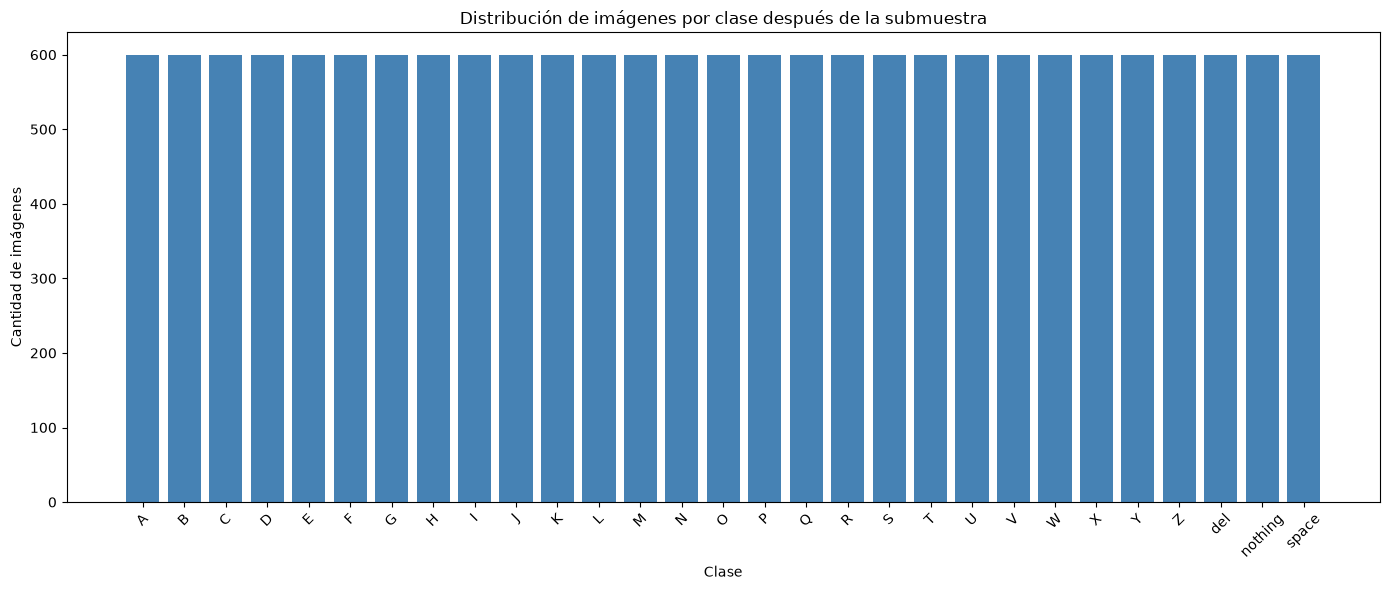

Mínimo de imágenes en una clase: 600
Máximo de imágenes en una clase: 600


In [3]:
conteo_clases = {clase: len(os.listdir(os.path.join(base_path, clase))) for clase in clases}

plt.figure(figsize=(14, 6))
plt.bar(conteo_clases.keys(), conteo_clases.values(), color='steelblue')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de imágenes por clase después de la submuestra')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Mínimo de imágenes en una clase:', min(conteo_clases.values()))
print('Máximo de imágenes en una clase:', max(conteo_clases.values()))

Todas las 29 clases quedaron con exactamente 600 imágenes, así que el dataset original tenía suficientes imágenes disponibles por letra y la submuestra queda perfectamente balanceada.

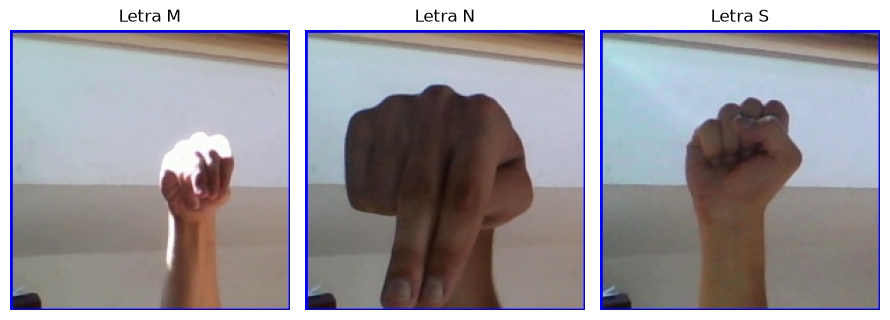

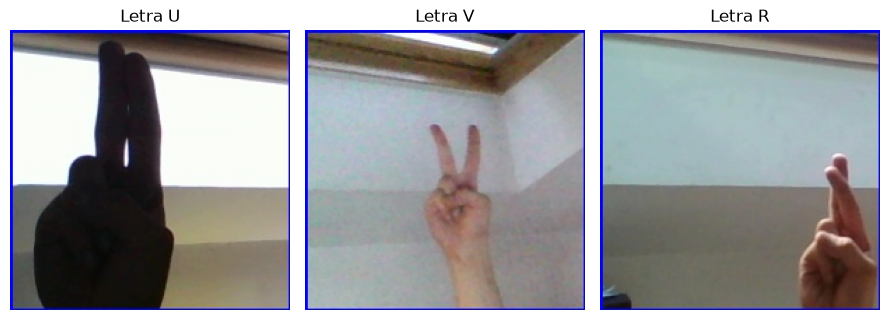

In [4]:
grupos_similares = [['M', 'N', 'S'], ['U', 'V', 'R']]

for grupo in grupos_similares:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 4))
    for ax, letra in zip(axes, grupo):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax.imshow(img)
        ax.set_title(f'Letra {letra}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Las letras M, N y S se parecen porque las tres se forman con el puño cerrado y el pulgar escondido debajo de los otros dedos, la diferencia entre ellas es solo la posición exacta del pulgar respecto a los dedos que lo cubren. Algo similar pasa con U, V y R, que se hacen con dos dedos extendidos y varían únicamente en si están juntos, separados o cruzados.

Para el modelo esto puede ser un problema porque son diferencias muy pequeñas en la imagen, casi a nivel de píxeles, y se pueden perder fácilmente con variaciones de ángulo, iluminación o resolución. Es probable que estas letras generen más confusión en la clasificación que otras con formas de mano claramente distintas.

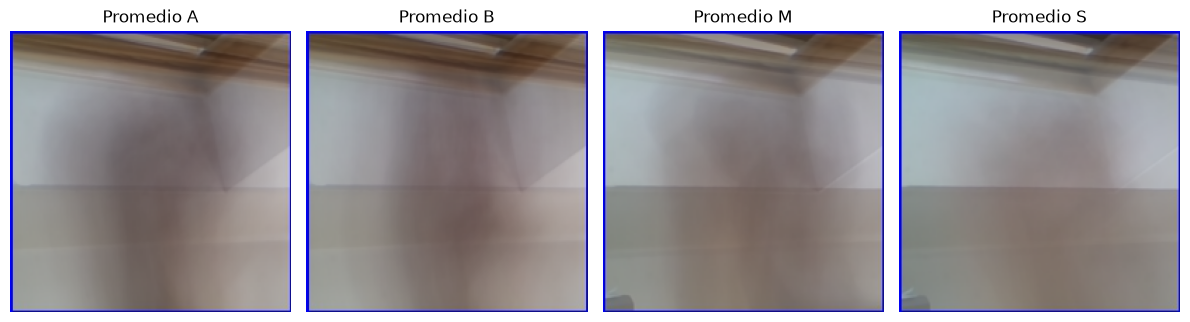

In [5]:
import numpy as np

clases_promedio = ['A', 'B', 'M', 'S']

fig, axes = plt.subplots(1, len(clases_promedio), figsize=(12, 4))

for ax, clase in zip(axes, clases_promedio):
    clase_path = os.path.join(base_path, clase)
    imagenes = os.listdir(clase_path)
    acumulador = np.zeros((200, 200, 3), dtype=np.float64)
    for nombre_img in imagenes:
        img = np.array(Image.open(os.path.join(clase_path, nombre_img)))
        acumulador += img
    promedio = (acumulador / len(imagenes)).astype(np.uint8)
    ax.imshow(promedio)
    ax.set_title(f'Promedio {clase}')
    ax.axis('off')

plt.tight_layout()
plt.show()

La imagen promedio se construye sumando pixel por pixel todas las fotos de una clase y dividiendo entre el total de imágenes. Si la seña se hace siempre en una posición y encuadre parecidos, el promedio sale nítido, con la forma de la mano reconocible. Si hay mucha variación de posición dentro de la clase, el promedio se ve borroso porque los bordes de la mano caen en lugares distintos de cada foto.

Lo que salió fue justamente eso último en las cuatro clases. El fondo, la pared y el borde de la puerta se ven casi idénticos entre A, B, M y S, lo que confirma que las fotos se tomaron con la cámara fija en la misma posición. Pero la mano en sí se pierde en una mancha difusa color piel en el centro de la imagen, sin bordes definidos, y esto pasa igual de fuerte en las cuatro letras, no solo en el grupo M y S que ya había marcado como confuso. Esto me dice que promediar pixeles crudos no sirve para distinguir señas, porque la posición de la mano varía lo suficiente dentro de cada clase como para que el promedio no conserve la forma. Confirma que el modelo va a necesitar aprender patrones espaciales locales en vez de depender de estadísticas simples de pixel.

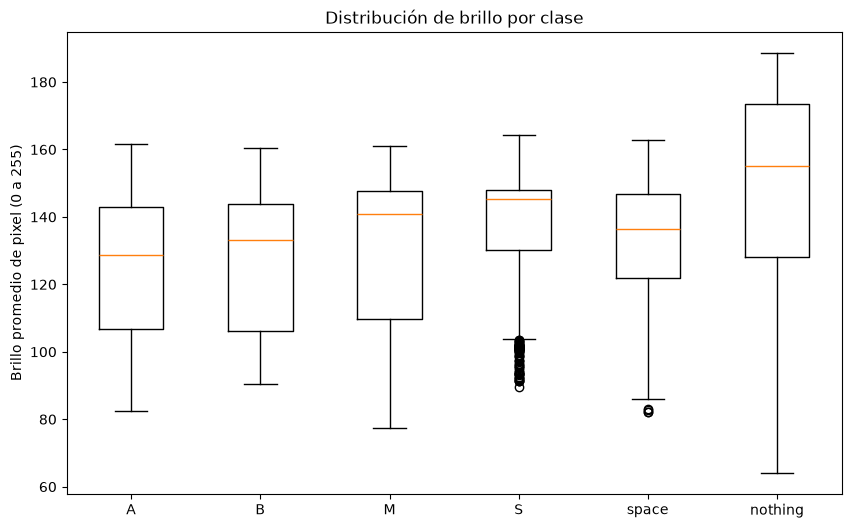

A: media=126.2, desviación=20.4
B: media=127.6, desviación=20.6
M: media=130.8, desviación=20.4
S: media=136.8, desviación=18.3
space: media=131.8, desviación=18.4
nothing: media=146.9, desviación=29.5


In [6]:
clases_brillo = ['A', 'B', 'M', 'S', 'space', 'nothing']
brillo_por_clase = {}

for clase in clases_brillo:
    clase_path = os.path.join(base_path, clase)
    valores = [np.array(Image.open(os.path.join(clase_path, nombre_img))).mean()
               for nombre_img in os.listdir(clase_path)]
    brillo_por_clase[clase] = valores

plt.figure(figsize=(10, 6))
plt.boxplot(brillo_por_clase.values(), tick_labels=brillo_por_clase.keys())
plt.ylabel('Brillo promedio de pixel (0 a 255)')
plt.title('Distribución de brillo por clase')
plt.show()

for clase, valores in brillo_por_clase.items():
    valores = np.array(valores)
    print(f'{clase}: media={valores.mean():.1f}, desviación={valores.std():.1f}')

Tomé el brillo promedio de pixel de cada imagen como métrica simple y comparé su distribución entre seis clases: cuatro letras (A, B, M, S) más las clases especiales space y nothing, que no corresponden a una letra sino a espacio y ausencia de seña.

A, B, M, S y space quedan en rangos de brillo muy parecidos entre sí, con medias entre 126 y 137 y desviaciones alrededor de 18 a 20. La clase nothing es la que se distingue: su media sube a casi 147 y su desviación es bastante más alta, cerca de 30. Tiene sentido, porque nothing captura escenas sin mano en el encuadre, así que queda más expuesta a cambios de iluminación de fondo y menos cubierta por la sombra que genera la propia mano cuando está presente. Para las letras entre sí el brillo no aporta mucho para distinguirlas, porque la iluminación depende más de la sesión de captura que de la seña específica.

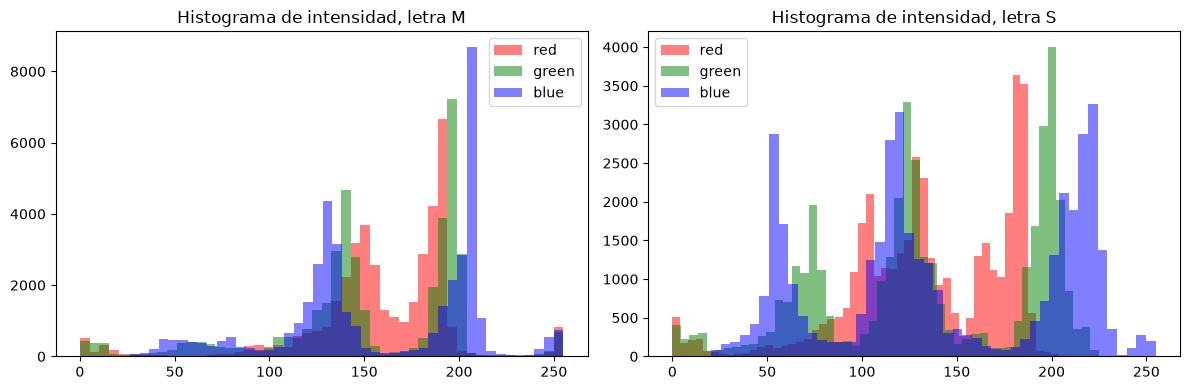

In [7]:
clases_hist = ['M', 'S']

fig, axes = plt.subplots(1, len(clases_hist), figsize=(12, 4))

for ax, clase in zip(axes, clases_hist):
    clase_path = os.path.join(base_path, clase)
    img_name = os.listdir(clase_path)[0]
    img = np.array(Image.open(os.path.join(clase_path, img_name)))
    for canal, color in enumerate(['red', 'green', 'blue']):
        ax.hist(img[:, :, canal].ravel(), bins=50, color=color, alpha=0.5, label=color)
    ax.set_title(f'Histograma de intensidad, letra {clase}')
    ax.legend()

plt.tight_layout()
plt.show()

Tomé una imagen representativa de M y otra de S y grafiqué la intensidad de cada canal de color por separado. En ambas letras los tres canales, rojo, verde y azul, siguen prácticamente la misma forma de distribución, solo desplazados un poco entre sí, lo cual es normal en piel bajo luz interior. No hay un canal que se dispare independiente de los otros.

Esto importa para la decisión de color contra escala de grises que documento más adelante en preprocesamiento, porque si los tres canales se mueven juntos, convertir a escala de grises no debería perder información relevante para distinguir la forma de la mano. La distribución en sí varía de imagen a imagen según el fondo y la sombra de esa foto puntual, como se ve en que M tiene un pico más marcado cerca de 200 y S tiene la masa más repartida entre valores bajos y altos, pero eso depende de la escena capturada en esa imagen particular, no de un patrón sistemático de la letra.

### Split de entrenamiento, validación y prueba

El set de prueba que trae Kaggle para este dataset viene con muy pocas imágenes, pensado más para una demo que para evaluar un modelo con seriedad. Por eso arme mi propio split a partir de los datos de entrenamiento que ya tengo descargados, en vez de depender de ese set oficial.

Uso una proporción 70 por ciento entrenamiento, 15 por ciento validación y 15 por ciento prueba, estratificada por clase para que las 29 letras mantengan la misma proporción en los tres conjuntos. Estratificar es importante acá porque aunque el dataset está balanceado en total, un split aleatorio simple podría dejar alguna clase con pocas imágenes en validación o prueba solo por azar, y eso haría más ruidosa la evaluación de esa clase en particular. Con 600 imágenes por clase, un 15 por ciento son 90 imágenes de prueba por letra, que me parece suficiente para medir el desempeño sin sacrificar demasiados datos de entrenamiento.

In [8]:
from sklearn.model_selection import train_test_split

archivos = []
etiquetas = []

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path):
        archivos.append(os.path.join(clase_path, nombre_img))
        etiquetas.append(clase)

archivos_train, archivos_temp, etiquetas_train, etiquetas_temp = train_test_split(
    archivos, etiquetas, test_size=0.30, stratify=etiquetas, random_state=42
)

archivos_val, archivos_test, etiquetas_val, etiquetas_test = train_test_split(
    archivos_temp, etiquetas_temp, test_size=0.50, stratify=etiquetas_temp, random_state=42
)

print('Entrenamiento:', len(archivos_train))
print('Validación:', len(archivos_val))
print('Prueba:', len(archivos_test))
print('Ejemplo de imágenes de prueba para la clase A:', etiquetas_test.count('A'))

Entrenamiento: 12180
Validación: 2610
Prueba: 2610
Ejemplo de imágenes de prueba para la clase A: 90


Con las 17400 imágenes de la submuestra, el split queda en 12180 para entrenamiento y 2610 para validación y otras 2610 para prueba, y la clase A aporta exactamente 90 imágenes al set de prueba, igual que le tocaría a cada una de las 29 clases si se reparte proporcional. Guardo las listas de rutas de archivo y etiquetas de cada conjunto para usarlas directamente cuando se arme el pipeline de entrenamiento en la entrega final.

## Preprocesamiento

Antes de entrenar cualquier modelo hay que dejar las 17400 imágenes en un formato manejable para el hardware disponible en el laboratorio. Las imágenes originales vienen a 200x200 en RGB, lo que da 40000 pixeles por canal y 120000 valores por imagen. Entrenar varias arquitecturas distintas sobre eso, incluyendo un Random Forest que no tiene forma de compartir cómputo entre pixeles como sí lo hace una convolución, sale caro en tiempo.

Por eso reduzco cada imagen a 64x64 antes de meterla a cualquier modelo. Esto deja 4096 pixeles por canal, casi 10 veces menos que el original, y sigue siendo suficiente resolución para que se distinga la forma general de la mano y la posición de los dedos, que es la información que realmente separa una letra de otra. El detalle fino que se pierde al reducir, como la textura de la piel o pequeñas variaciones de sombra, no aporta a la tarea de clasificación y hasta podría hacer que el modelo se sobreajuste a detalles irrelevantes de cada foto en particular.

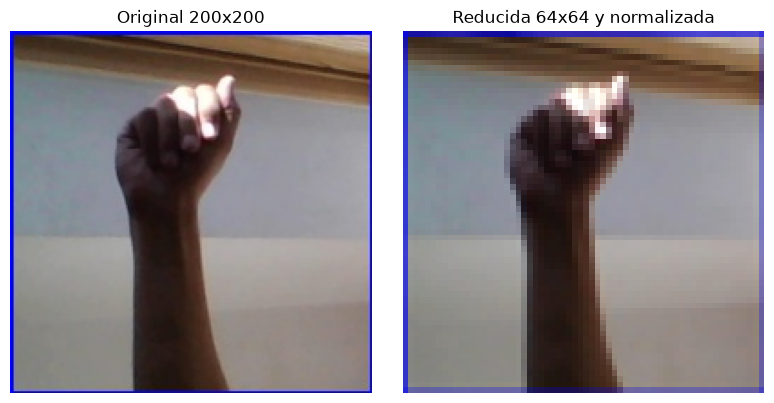

Rango de valores original: 0 a 255
Rango de valores normalizado: 0.027 a 1.0


In [9]:
TAMANO_DESTINO = (64, 64)

clase_ejemplo = 'A'
clase_ejemplo_path = os.path.join(base_path, clase_ejemplo)
img_path = os.path.join(clase_ejemplo_path, os.listdir(clase_ejemplo_path)[0])

img_original = Image.open(img_path)
img_original_array = np.array(img_original)

img_reducida = img_original.resize(TAMANO_DESTINO)
img_normalizada = np.array(img_reducida) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original_array)
axes[0].set_title(f'Original {img_original.size[0]}x{img_original.size[1]}')
axes[0].axis('off')
axes[1].imshow(img_normalizada)
axes[1].set_title(f'Reducida {TAMANO_DESTINO[0]}x{TAMANO_DESTINO[1]} y normalizada')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Rango de valores original:', img_original_array.min(), 'a', img_original_array.max())
print('Rango de valores normalizado:', round(img_normalizada.min(), 3), 'a', round(img_normalizada.max(), 3))

Para la normalización divido cada pixel entre 255 para dejarlo en el rango de 0 a 1, en vez de estandarizar restando la media y dividiendo entre la desviación estándar. Con el rango 0 a 1 alcanza para este caso porque las imágenes ya vienen en una escala de iluminación bastante uniforme, según lo que vi en la distribución de brillo por clase, así que no hace falta el paso extra de calcular media y desviación por canal sobre todo el set de entrenamiento.

Decidí mantener las imágenes a color en vez de pasarlas a escala de grises. Lo pensé por el ahorro de memoria que da trabajar con un solo canal, pero en el histograma de intensidad de M y S los tres canales de color se mueven prácticamente juntos, lo que confirma que no hay señal de color que separe las letras entre sí, la información está en la forma de la mano, no en el tono. Aun así, dejo los tres canales porque el costo de cómputo ya se resolvió con la reducción a 64x64, y quitar canales en este punto sería una optimización que no hace falta para el tamaño de este laboratorio.

No aplico ningún filtro adicional de suavizado o realce de bordes. Las fotos ya vienen limpias, tomadas con una cámara fija y sin ruido visible, y el problema real que encontré en el análisis exploratorio, la confusión entre M, N, S y entre U, V, R, es de forma de mano y no de calidad de imagen, así que un filtro no ayudaría ahí. El único preprocesamiento que aplico es resize a 64x64 y la normalización a 0 y 1.

## Selección de modelos

Para la entrega final voy a entrenar y comparar cuatro modelos sobre las imágenes ya reducidas a 64x64 en color: dos redes convolucionales con distinta profundidad, una red totalmente conectada como referencia sin convoluciones, y un algoritmo clásico de machine learning como punto de comparación fuera del mundo de redes neuronales.

La primera CNN es una arquitectura chica, pensada como línea base. Tiene tres bloques de convolución con 32, 64 y 128 filtros respectivamente, cada uno seguido de max pooling para ir reduciendo el tamaño espacial, y termina en una capa densa de 128 neuronas antes de la salida de 29 clases con softmax. La segunda CNN agrega un cuarto bloque convolucional con 256 filtros y normalización por lotes después de cada convolución, además de dropout antes de la capa densa final. La idea es medir si la profundidad y la regularización extra realmente ayudan con este dataset o si con el tamaño de submuestra que tengo ya alcanza con la arquitectura más simple, sobre todo pensando en las letras que se confunden entre sí como M, N, S y U, V, R, donde una red más profunda podría captar mejor las diferencias sutiles de posición del pulgar o los dedos.

Como referencia sin convoluciones entreno una red totalmente conectada que recibe la imagen aplanada, 64 por 64 por 3 valores de entrada, pasa por dos capas densas de 256 y 128 neuronas y termina en la salida de 29 clases. Esta red no tiene forma de aprovechar que los pixeles cercanos están relacionados espacialmente, así que sirve para confirmar si la estructura convolucional realmente aporta algo sobre este problema o si una red densa ya es suficiente.

Para el algoritmo alterno elijo Random Forest en vez de SVM o KNN. Con casi 12180 imágenes de entrenamiento y vectores de más de 12000 valores por imagen, un KNN sale caro porque tiene que calcular distancia contra todo el set de entrenamiento en cada predicción, y un SVM con kernel no lineal escala mal en tiempo de entrenamiento con este volumen de datos. Random Forest entrena razonablemente rápido incluso con muchas variables, no necesita que los datos estén escalados de una forma particular, y de paso da una medida de importancia por pixel que puede ser útil para entender en qué zonas de la imagen se está fijando el modelo, algo que sirve de comparación frente a lo que aprenden las CNN.

## Plan de procesamiento de imágenes

Resumo acá todo el camino que recorre una imagen desde el dataset crudo de Kaggle hasta quedar lista para entrar a cualquiera de los modelos que voy a entrenar.

1. Dataset crudo: el dataset original de Kaggle trae miles de imágenes por letra. De ahí tomé una submuestra de 600 imágenes por clase con semilla fija en 42, que es la que vive en la carpeta data de este proyecto y con la que se trabajó todo el análisis exploratorio.
2. División en conjuntos: sobre esas 17400 imágenes aplico el split estratificado 70 por ciento entrenamiento, 15 por ciento validación y 15 por ciento prueba que definí antes, para que ningún conjunto quede sesgado hacia unas letras más que otras.
3. Resize a 64x64: cada imagen pasa de 200x200 a 64x64 para bajar el costo de cómputo sin perder la forma general de la mano.
4. Normalización: divido los valores de pixel entre 255 para dejarlos en el rango de 0 a 1, que es el formato que esperan las capas de entrada de las redes.
5. Aumentos de datos, solo sobre el conjunto de entrenamiento: acá hay que tener cuidado porque no todos los aumentos típicos de visión por computadora tienen sentido para señas. Voy a aplicar rotaciones leves, de unos 10 a 15 grados como máximo, pequeños corrimientos de posición y zoom leve, y variaciones menores de brillo y contraste, para simular la variabilidad de ángulo y distancia a la cámara que ya noté en el análisis exploratorio. Lo que evito por completo es el flip horizontal, porque muchas señas del alfabeto dependen de qué mano y en qué orientación se hacen, y voltear la imagen puede convertir una seña válida en una que no corresponde a esa letra o directamente en otra letra distinta. Por la misma razón tampoco aplico flip vertical ni rotaciones grandes que puedan hacer que una seña se parezca a otra, como podría pasar entre M, N y S si se rota demasiado.
6. Conversión a tensores: ya con las imágenes en 64x64, normalizadas y aumentadas cuando corresponde, las convierto a tensores. Para las CNN y la red totalmente conectada esto es un tensor de forma 64 por 64 por 3 por imagen. Para el Random Forest aplano ese mismo tensor a un vector de una dimensión, porque ese modelo no trabaja con estructura espacial como sí lo hacen las redes.

## Ejercicio 4: modelos CNN

Entreno acá las dos arquitecturas convolucionales que dejé descritas en la sección de selección de modelos, reutilizando el split 70/15/15 y el resize a 64x64 con normalización que ya definí antes. Para cada una pruebo primero un par de configuraciones de entrenamiento distintas sobre pocas épocas para no perder tiempo entrenando algo mal ajustado, y con la configuración que mejor le va sigo entrenando más épocas con paro temprano hasta que la red deja de mejorar en validación.

In [10]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1786062553.807601  159762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786062553.808029  159762 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1786062555.201636  159762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786062555.201934  159762 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [11]:
clase_a_indice = {clase: i for i, clase in enumerate(clases)}

def cargar_conjunto(rutas, etiquetas_texto):
    X = np.zeros((len(rutas), 64, 64, 3), dtype=np.float32)
    y = np.zeros(len(rutas), dtype=np.int32)
    for i, (ruta, etiqueta) in enumerate(zip(rutas, etiquetas_texto)):
        img = Image.open(ruta).resize((64, 64))
        X[i] = np.array(img) / 255.0
        y[i] = clase_a_indice[etiqueta]
    return X, y

X_train, y_train = cargar_conjunto(archivos_train, etiquetas_train)
X_val, y_val = cargar_conjunto(archivos_val, etiquetas_val)
X_test, y_test = cargar_conjunto(archivos_test, etiquetas_test)

print('Forma X_train:', X_train.shape)
print('Forma X_val:', X_val.shape)
print('Forma X_test:', X_test.shape)

Forma X_train: (12180, 64, 64, 3)
Forma X_val: (2610, 64, 64, 3)
Forma X_test: (2610, 64, 64, 3)


In [12]:
def crear_early_stop():
    return tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def matriz_y_confusiones(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=plt.gca(), xticks_rotation=90, colorbar=False, cmap='Blues')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    pares = []
    for i in range(len(clases)):
        for j in range(len(clases)):
            if cm_off[i, j] > 0:
                pares.append((clases[i], clases[j], cm_off[i, j]))
    pares.sort(key=lambda x: -x[2])
    print(f'Pares mas confundidos en {titulo} (real -> predicho: cantidad):')
    for real, pred, cant in pares[:8]:
        print(f'{real} -> {pred}: {cant}')
    return cm

def construir_cnn_base():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

In [13]:
configuraciones_base = [
    {'learning_rate': 1e-3, 'batch_size': 32},
    {'learning_rate': 1e-3, 'batch_size': 64},
    {'learning_rate': 5e-4, 'batch_size': 64},
]

resultados_sweep_base = []
for config in configuraciones_base:
    modelo = construir_cnn_base()
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    historial = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                             batch_size=config['batch_size'], epochs=6, verbose=0)
    val_acc = historial.history['val_accuracy'][-1]
    resultados_sweep_base.append({**config, 'val_accuracy': val_acc})
    print(f"lr={config['learning_rate']}, batch={config['batch_size']} -> val_accuracy={val_acc:.4f}")

mejor_config_base = max(resultados_sweep_base, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion CNN base:', mejor_config_base)

lr=0.001, batch=32 -> val_accuracy=0.9487


lr=0.001, batch=64 -> val_accuracy=0.9161


lr=0.0005, batch=64 -> val_accuracy=0.8724

Mejor configuracion CNN base: {'learning_rate': 0.001, 'batch_size': 32, 'val_accuracy': 0.9486590027809143}


In [14]:
cnn_base = construir_cnn_base()
cnn_base.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_config_base['learning_rate']),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_base = cnn_base.fit(X_train, y_train, validation_data=(X_val, y_val),
                                batch_size=mejor_config_base['batch_size'], epochs=18,
                                callbacks=[crear_early_stop()], verbose=2)

test_loss_base, test_acc_base = cnn_base.evaluate(X_test, y_test, verbose=0)
print('\nCNN base, accuracy en prueba:', round(test_acc_base, 4))
print('CNN base, loss en prueba:', round(test_loss_base, 4))

Epoch 1/18


381/381 - 10s - 25ms/step - accuracy: 0.3503 - loss: 2.2192 - val_accuracy: 0.6498 - val_loss: 1.0963


Epoch 2/18


381/381 - 9s - 24ms/step - accuracy: 0.7718 - loss: 0.7154 - val_accuracy: 0.8226 - val_loss: 0.5322


Epoch 3/18


...

Epoch 10/18


381/381 - 10s - 27ms/step - accuracy: 0.9828 - loss: 0.0538 - val_accuracy: 0.9621 - val_loss: 0.1497


Epoch 11/18


381/381 - 11s - 29ms/step - accuracy: 0.9935 - loss: 0.0215 - val_accuracy: 0.9579 - val_loss: 0.1696



CNN base, accuracy en prueba: 0.9456
CNN base, loss en prueba: 0.1724


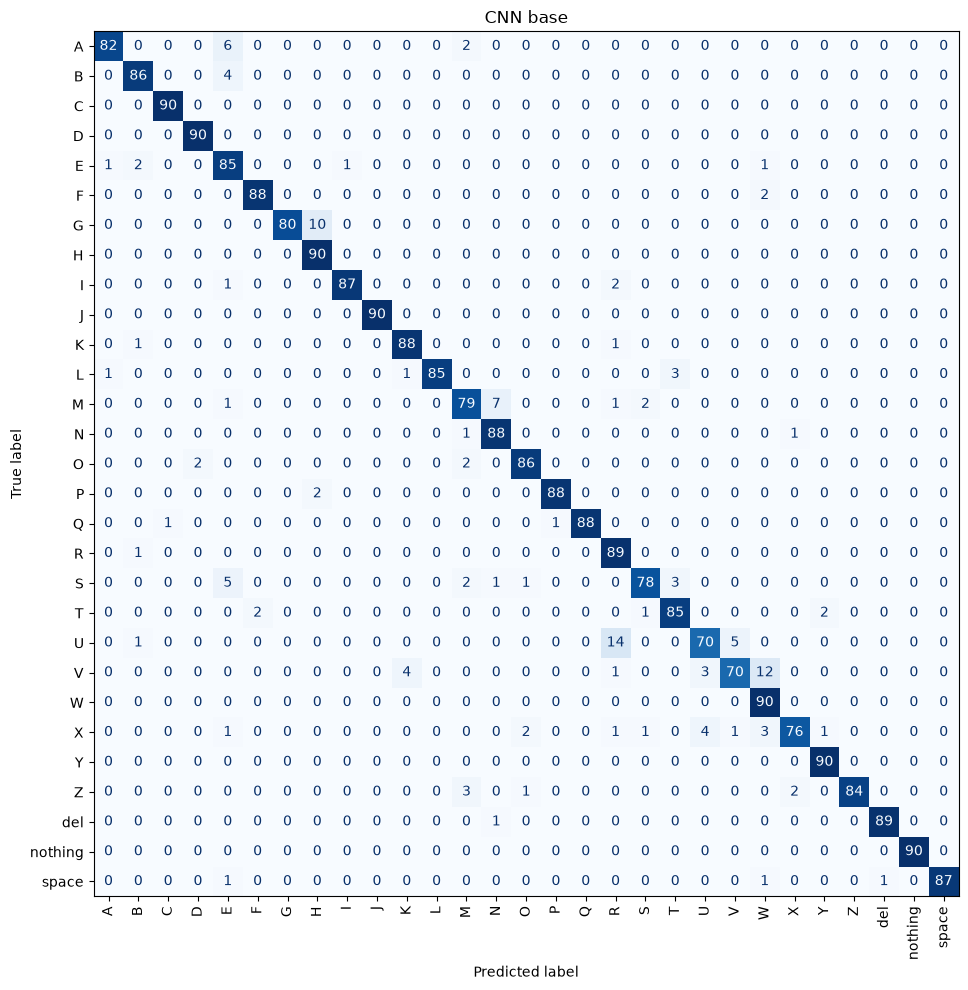

Pares mas confundidos en CNN base (real -> predicho: cantidad):
U -> R: 14
V -> W: 12
G -> H: 10
M -> N: 7
A -> E: 6
S -> E: 5
U -> V: 5
B -> E: 4


In [15]:
y_pred_base = cnn_base.predict(X_test, verbose=0).argmax(axis=1)
cm_base = matriz_y_confusiones(y_test, y_pred_base, 'CNN base')

De las tres configuraciones que probé, la que ganó fue learning rate de 0.001 con batch de 32, con 0.9487 de accuracy en validación tras solo 6 épocas, bastante arriba de las otras dos combinaciones. Con esa configuración entrené más épocas y el paro temprano cortó en la época 11 de las 18 que dejé como tope, cuando la pérdida de validación dejó de bajar. La red llegó a 0.9456 de accuracy en el set de prueba, con una pérdida de 0.1724.

La matriz de confusión confirma bastante bien lo que había anotado en el análisis exploratorio: los pares que más se confunden son U con R, V con W y G con H, además de M con N, que es justo uno de los grupos que marqué como visualmente parecidos por la posición del pulgar. Ninguno de estos pares pasa de 14 imágenes mal clasificadas sobre 90 posibles por clase, así que aunque la confusión existe, no domina el resultado.

### CNN profunda

In [16]:
def construir_cnn_profunda():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(256, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

configuraciones_profunda = [
    {'learning_rate': 1e-3, 'batch_size': 64},
    {'learning_rate': 5e-4, 'batch_size': 64},
]

resultados_sweep_profunda = []
for config in configuraciones_profunda:
    modelo = construir_cnn_profunda()
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    historial = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                             batch_size=config['batch_size'], epochs=6, verbose=0)
    val_acc = historial.history['val_accuracy'][-1]
    resultados_sweep_profunda.append({**config, 'val_accuracy': val_acc})
    print(f"lr={config['learning_rate']}, batch={config['batch_size']} -> val_accuracy={val_acc:.4f}")

mejor_config_profunda = max(resultados_sweep_profunda, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion CNN profunda:', mejor_config_profunda)

lr=0.001, batch=64 -> val_accuracy=0.0502


lr=0.0005, batch=64 -> val_accuracy=0.4674

Mejor configuracion CNN profunda: {'learning_rate': 0.0005, 'batch_size': 64, 'val_accuracy': 0.4674329459667206}


In [17]:
cnn_profunda = construir_cnn_profunda()
cnn_profunda.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_config_profunda['learning_rate']),
                       loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_profunda = cnn_profunda.fit(X_train, y_train, validation_data=(X_val, y_val),
                                        batch_size=mejor_config_profunda['batch_size'], epochs=18,
                                        callbacks=[crear_early_stop()], verbose=2)

test_loss_profunda, test_acc_profunda = cnn_profunda.evaluate(X_test, y_test, verbose=0)
print('\nCNN profunda, accuracy en prueba:', round(test_acc_profunda, 4))
print('CNN profunda, loss en prueba:', round(test_loss_profunda, 4))

Epoch 1/18


191/191 - 21s - 112ms/step - accuracy: 0.0628 - loss: 3.2902 - val_accuracy: 0.0345 - val_loss: 3.9718


Epoch 2/18


191/191 - 21s - 107ms/step - accuracy: 0.1085 - loss: 3.0006 - val_accuracy: 0.0510 - val_loss: 3.9419


Epoch 3/18


...

Epoch 17/18


191/191 - 21s - 107ms/step - accuracy: 0.3478 - loss: 1.8503 - val_accuracy: 0.7199 - val_loss: 0.9907


Epoch 18/18


191/191 - 20s - 106ms/step - accuracy: 0.3588 - loss: 1.8108 - val_accuracy: 0.4943 - val_loss: 1.5408



CNN profunda, accuracy en prueba: 0.7835
CNN profunda, loss en prueba: 0.9875


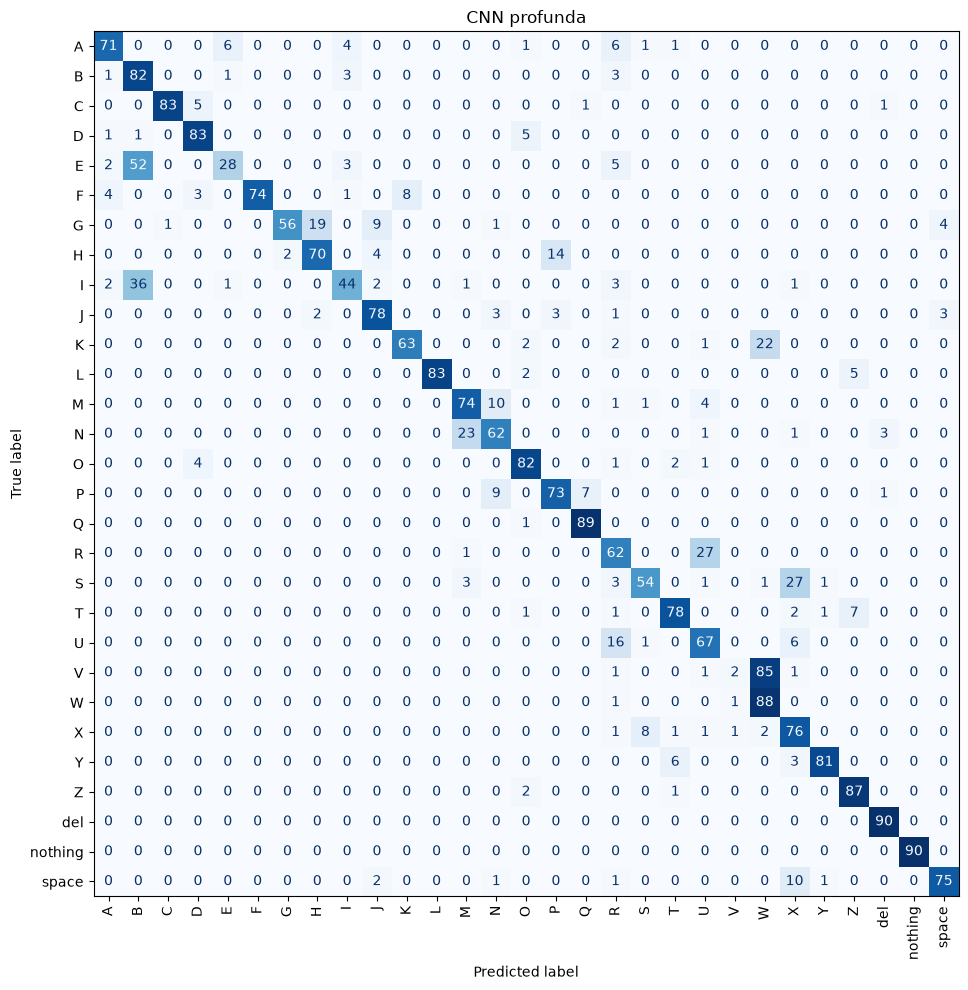

Pares mas confundidos en CNN profunda (real -> predicho: cantidad):
V -> W: 85
E -> B: 52
I -> B: 36
R -> U: 27
S -> X: 27
N -> M: 23
K -> W: 22
G -> H: 19


In [18]:
y_pred_profunda = cnn_profunda.predict(X_test, verbose=0).argmax(axis=1)
cm_profunda = matriz_y_confusiones(y_test, y_pred_profunda, 'CNN profunda')

Acá el resultado no fue el que esperaba. En el sweep, la configuración con learning rate de 0.001 prácticamente colapsó, con 0.0502 de accuracy en validación, casi el nivel de adivinar al azar entre 29 clases. La de 0.0005 rindió mejor pero se quedó corta, 0.4674 tras 6 épocas. Con esa segunda configuración entrené las 18 épocas completas sin que el paro temprano cortara antes, y aun así la accuracy de entrenamiento terminó en apenas 0.36, mientras que la de validación fue bastante inestable, subió hasta 0.795 en la época 15 y volvió a caer a 0.494 en la última. La accuracy final en prueba quedó en 0.7835, bien por debajo de la CNN base.

Creo que la explicación tiene dos partes. Primero, agregar el cuarto bloque convolucional y la normalización por lotes hace la red más sensible al learning rate, como se ve en que 0.001 la hizo colapsar mientras que a la CNN base ese mismo valor le funcionó bien. Segundo, la normalización por lotes se comporta distinto en modo entrenamiento, donde usa estadísticas del batch actual, que en modo evaluación, donde usa el promedio acumulado, y eso puede explicar por qué la accuracy de entrenamiento se ve más baja y ruidosa que la de validación durante buena parte del entrenamiento. La matriz de confusión también lo refleja, con pares como V y W llegando a 85 imágenes mal clasificadas, muy por encima de cualquier par de la CNN base. Con el presupuesto de épocas que usé, la arquitectura más profunda no terminó de converger, así que para este dataset y este tiempo de entrenamiento la CNN base es la opción más confiable.

### Comparacion y seleccion de la mejor CNN

In [19]:
print('CNN base, accuracy en prueba:', round(test_acc_base, 4))
print('CNN profunda, accuracy en prueba:', round(test_acc_profunda, 4))

if test_acc_base >= test_acc_profunda:
    mejor_cnn = cnn_base
    nombre_mejor_cnn = 'CNN base'
    mejor_hparams_cnn = mejor_config_base
    construir_mejor_cnn = construir_cnn_base
    test_acc_mejor_cnn = test_acc_base
else:
    mejor_cnn = cnn_profunda
    nombre_mejor_cnn = 'CNN profunda'
    mejor_hparams_cnn = mejor_config_profunda
    construir_mejor_cnn = construir_cnn_profunda
    test_acc_mejor_cnn = test_acc_profunda

print('\nMejor CNN:', nombre_mejor_cnn, 'con accuracy en prueba de', round(test_acc_mejor_cnn, 4))

CNN base, accuracy en prueba: 0.9456
CNN profunda, accuracy en prueba: 0.7835

Mejor CNN: CNN base con accuracy en prueba de 0.9456


Me quedo con la CNN base para el resto de comparaciones. La diferencia entre 0.9456 y 0.7835 de accuracy en prueba es grande, y como discutí arriba tiene que ver con que la arquitectura más profunda necesitaba más tiempo de entrenamiento del que le di. No descarto que con más épocas o un learning rate con calentamiento gradual la CNN profunda termine superando a la base, pero dentro del presupuesto de cómputo de este laboratorio la base es la que realmente funciona.

## Ejercicio 5: red neuronal simple

Entreno ahora la red totalmente conectada que describí en la selección de modelos, sobre las mismas imágenes 64x64 en color, para comparar contra la mejor CNN.

In [20]:
def construir_fc():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

fc = construir_fc()
fc.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_fc = fc.fit(X_train, y_train, validation_data=(X_val, y_val),
                        batch_size=64, epochs=18, callbacks=[crear_early_stop()], verbose=2)

test_loss_fc, test_acc_fc = fc.evaluate(X_test, y_test, verbose=0)
print('\nRed totalmente conectada, accuracy en prueba:', round(test_acc_fc, 4))
print('Red totalmente conectada, loss en prueba:', round(test_loss_fc, 4))

Epoch 1/18


191/191 - 4s - 20ms/step - accuracy: 0.0802 - loss: 3.4938 - val_accuracy: 0.1123 - val_loss: 3.1689


Epoch 2/18


191/191 - 3s - 16ms/step - accuracy: 0.1569 - loss: 2.9720 - val_accuracy: 0.1693 - val_loss: 2.8734


Epoch 3/18


...

Epoch 17/18


191/191 - 3s - 16ms/step - accuracy: 0.6989 - loss: 0.9016 - val_accuracy: 0.6100 - val_loss: 1.1659


Epoch 18/18


191/191 - 3s - 16ms/step - accuracy: 0.7063 - loss: 0.8675 - val_accuracy: 0.6284 - val_loss: 1.1100



Red totalmente conectada, accuracy en prueba: 0.6349
Red totalmente conectada, loss en prueba: 1.0754


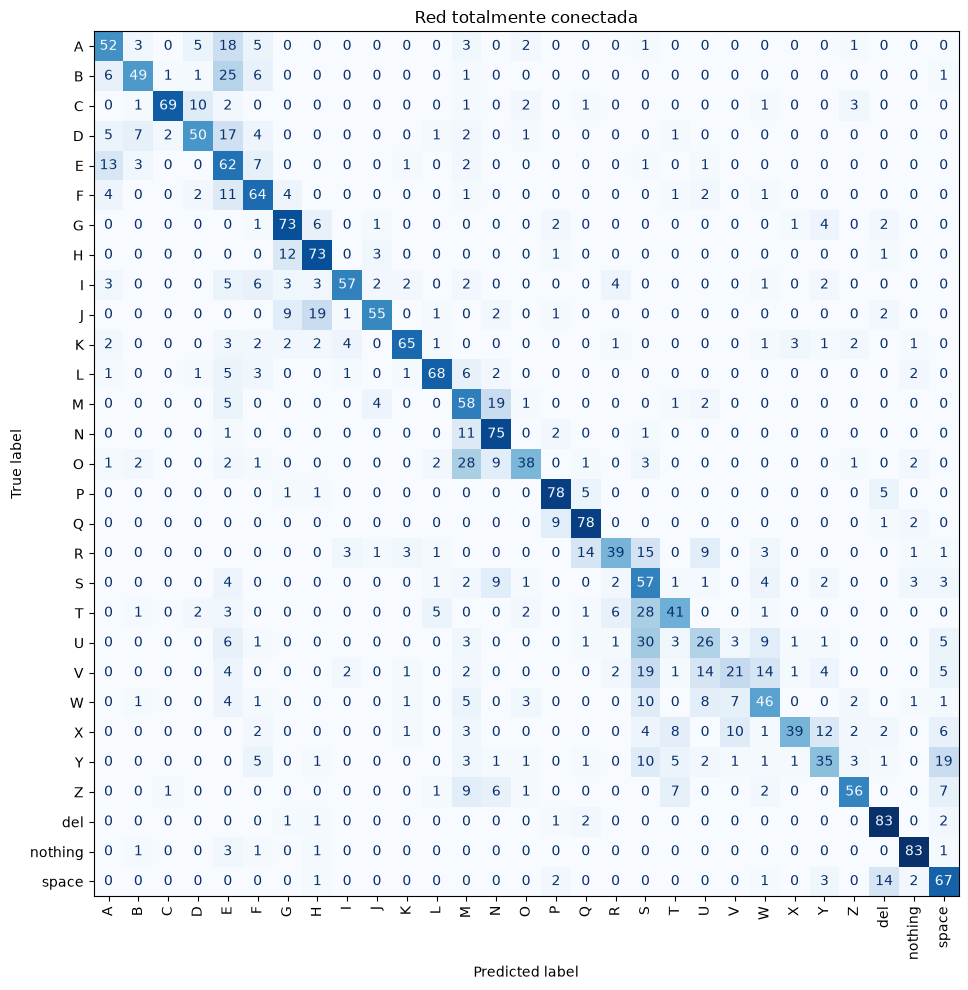

Pares mas confundidos en Red totalmente conectada (real -> predicho: cantidad):
U -> S: 30
O -> M: 28
T -> S: 28
B -> E: 25
J -> H: 19
M -> N: 19
V -> S: 19
Y -> space: 19


In [21]:
y_pred_fc = fc.predict(X_test, verbose=0).argmax(axis=1)
cm_fc = matriz_y_confusiones(y_test, y_pred_fc, 'Red totalmente conectada')

La red totalmente conectada llegó a 0.6349 de accuracy en prueba, bien por debajo de la CNN base y hasta por debajo de la CNN profunda. A diferencia de las CNN, acá ni siquiera llegó a estabilizarse del todo en 18 épocas, la accuracy de entrenamiento seguía subiendo al final, 0.7063, sin señales claras de que el paro temprano fuera a cortar pronto.

Lo más revelador es la matriz de confusión. Los pares que más confunde, como U con S, O con M, T con S o Y con espacio, no son necesariamente los que yo había marcado como visualmente parecidos en el análisis exploratorio. Esto encaja con lo que vi en la imagen promedio por clase, donde noté que la posición de la mano varía lo suficiente dentro de cada clase como para que un pixel en una posición fija no signifique lo mismo de una foto a otra. La red totalmente conectada trata cada pixel como una entrada independiente y no tiene forma de reconocer que un patrón de bordes es el mismo sin importar en qué parte de la imagen aparece, así que termina confundiendo letras por razones que no tienen que ver con el parecido real de la seña. Las CNN sí tienen esa invariancia espacial gracias a las convoluciones, y por eso les va mejor incluso cuando, como la CNN profunda, no terminan de converger del todo.

## Ejercicio 6: algoritmo alterno, Random Forest

Ya justifiqué en la selección de modelos por qué elijo Random Forest sobre SVM o KNN para este problema: con miles de imágenes y vectores de más de 12000 valores, KNN sale caro en tiempo de predicción y SVM con kernel no lineal escala mal en tiempo de entrenamiento. Acá entreno el Random Forest sobre las imágenes aplanadas y me enfoco en los resultados.

In [22]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

rf_base = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_base.fit(X_train_flat, y_train)

val_acc_rf_base = rf_base.score(X_val_flat, y_val)
test_acc_rf_base = rf_base.score(X_test_flat, y_test)
print('Random Forest base (200 arboles, sin limite de profundidad)')
print('accuracy en validacion:', round(val_acc_rf_base, 4))
print('accuracy en prueba:', round(test_acc_rf_base, 4))

Random Forest base (200 arboles, sin limite de profundidad)
accuracy en validacion: 0.9621
accuracy en prueba: 0.9582


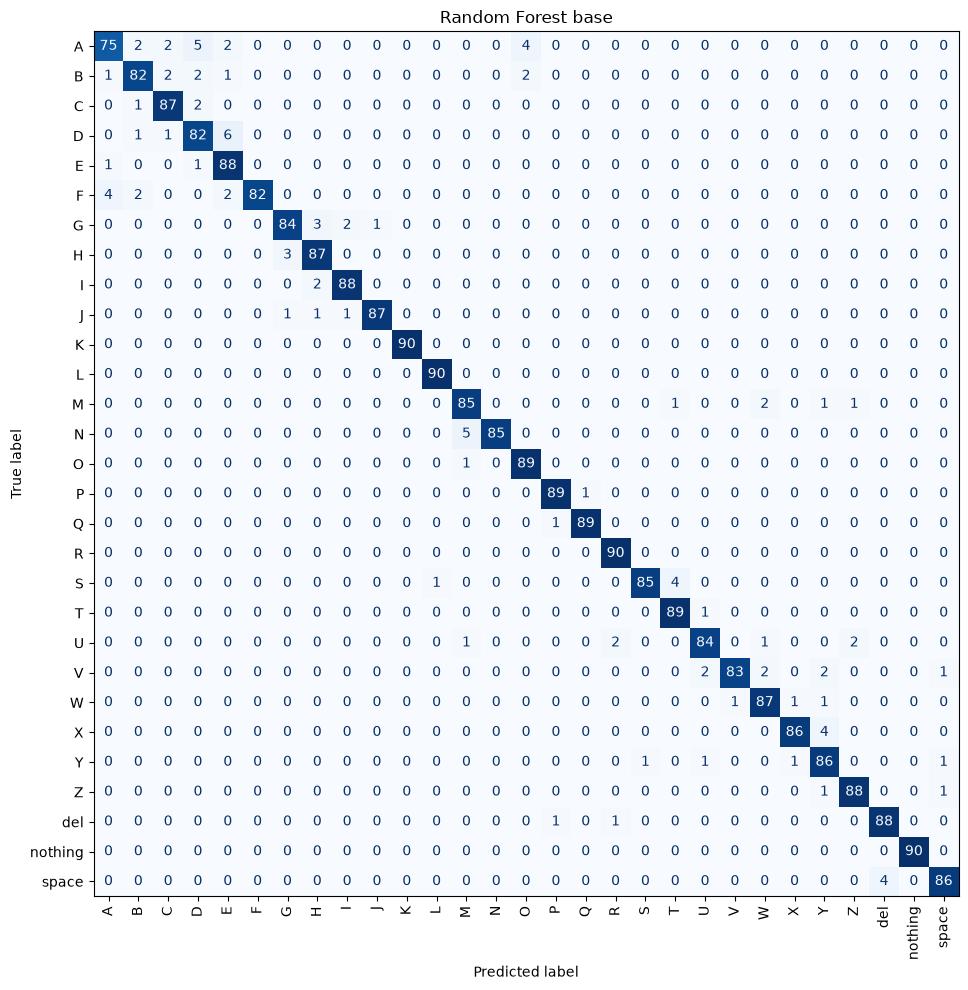

Pares mas confundidos en Random Forest base (real -> predicho: cantidad):
D -> E: 6
A -> D: 5
N -> M: 5
A -> O: 4
F -> A: 4
S -> T: 4
X -> Y: 4
space -> del: 4


In [23]:
y_pred_rf_base = rf_base.predict(X_test_flat)
cm_rf_base = matriz_y_confusiones(y_test, y_pred_rf_base, 'Random Forest base')

Con 200 árboles y sin límite de profundidad, el Random Forest llegó a 0.9621 de accuracy en validación y 0.9582 en prueba, ya superando a la CNN base sin haber ajustado nada todavía. Me sorprendió, porque este modelo trabaja sobre exactamente la misma representación de pixeles aplanados que la red totalmente conectada, y esa red rindió mucho peor.

Pensándolo mejor tiene sentido. Un árbol de decisión no necesita una regla global como una red densa, cada árbol puede aprender reglas del tipo si el pixel en tal posición supera tal valor entonces probablemente es tal clase, y con cientos de árboles votando sobre subconjuntos distintos de pixeles el conjunto termina siendo bastante robusto. Esto conecta con lo que vi en la imagen promedio por clase: el fondo, la pared y el borde de la puerta salían casi idénticos entre clases porque la cámara estaba fija, así que hay pixeles de fondo consistentes que un árbol puede usar como referencia indirecta de dónde suele caer la mano, algo que una red totalmente conectada con descenso de gradiente no está aprovechando tan bien en el mismo número de épocas. La matriz de confusión sale bastante limpia, el par que más se confunde, D con E, no pasa de 6 imágenes.

### Ajuste de parametros del Random Forest

In [24]:
configuraciones_rf = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 40},
]

resultados_rf = [{'n_estimators': 200, 'max_depth': None, 'val_accuracy': val_acc_rf_base}]
for config in configuraciones_rf:
    rf = RandomForestClassifier(n_estimators=config['n_estimators'], max_depth=config['max_depth'],
                                  random_state=42, n_jobs=-1)
    rf.fit(X_train_flat, y_train)
    val_acc = rf.score(X_val_flat, y_val)
    resultados_rf.append({**config, 'val_accuracy': val_acc})
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} -> val_accuracy={val_acc:.4f}")

mejor_config_rf = max(resultados_rf, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion Random Forest:', mejor_config_rf)

n_estimators=100, max_depth=None -> val_accuracy=0.9579


n_estimators=300, max_depth=None -> val_accuracy=0.9640


n_estimators=200, max_depth=10 -> val_accuracy=0.9054


n_estimators=200, max_depth=20 -> val_accuracy=0.9582


n_estimators=200, max_depth=40 -> val_accuracy=0.9617

Mejor configuracion Random Forest: {'n_estimators': 300, 'max_depth': None, 'val_accuracy': 0.963984674329502}


Random Forest ajustado, accuracy en prueba: 0.9598
Random Forest base, accuracy en prueba: 0.9582


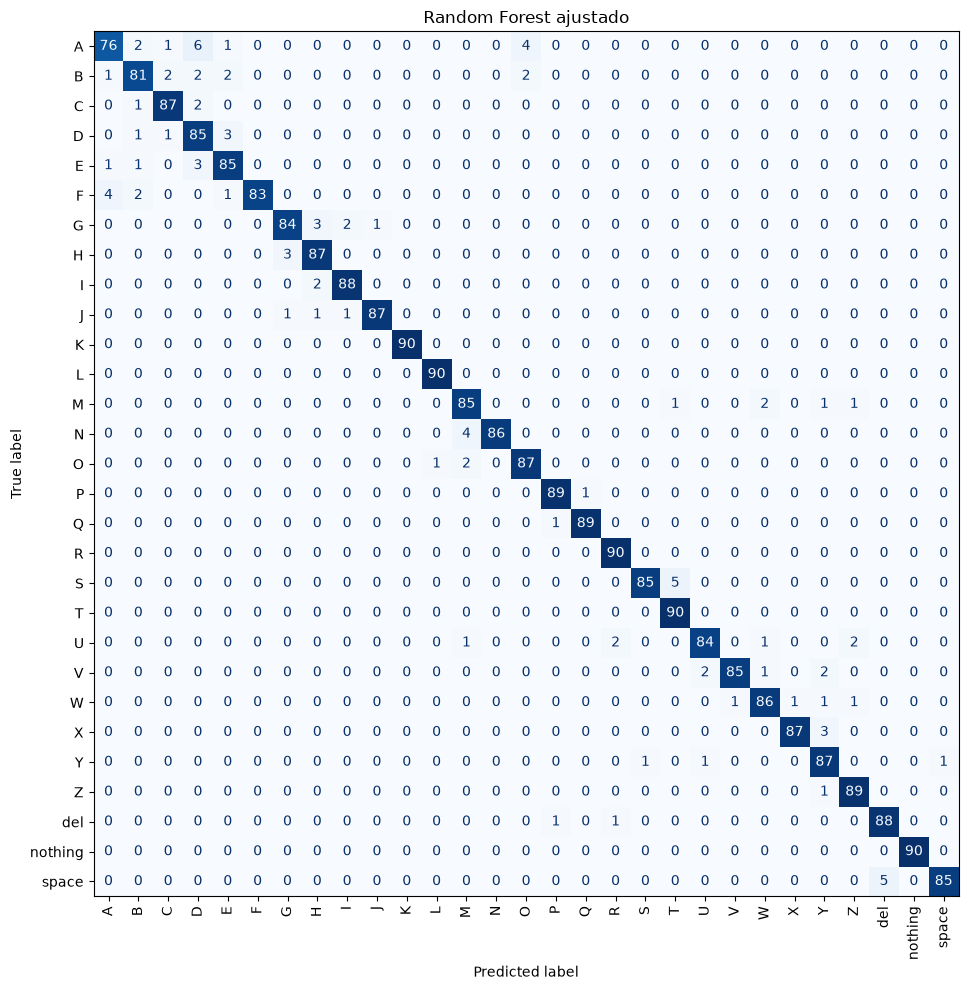

Pares mas confundidos en Random Forest ajustado (real -> predicho: cantidad):
A -> D: 6
S -> T: 5
space -> del: 5
A -> O: 4
F -> A: 4
N -> M: 4
D -> E: 3
E -> D: 3


In [25]:
rf_tuned = RandomForestClassifier(n_estimators=mejor_config_rf['n_estimators'],
                                    max_depth=mejor_config_rf['max_depth'],
                                    random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_flat, y_train)

test_acc_rf_tuned = rf_tuned.score(X_test_flat, y_test)
print('Random Forest ajustado, accuracy en prueba:', round(test_acc_rf_tuned, 4))
print('Random Forest base, accuracy en prueba:', round(test_acc_rf_base, 4))

y_pred_rf_tuned = rf_tuned.predict(X_test_flat)
cm_rf_tuned = matriz_y_confusiones(y_test, y_pred_rf_tuned, 'Random Forest ajustado')

El parámetro que más movió la aguja fue la profundidad máxima, no la cantidad de árboles. Limitar la profundidad a 10 hundió la accuracy de validación a 0.9054, bastante por debajo del resto, mientras que subir a 200 o 300 árboles sin límite de profundidad se quedó siempre arriba de 0.96. Con 29 clases y más de 12000 variables de entrada, cada árbol necesita crecer bastante para separar las clases, así que cortar la profundidad le quita capacidad al modelo en vez de ayudarlo a generalizar mejor.

La configuración ganadora fue 300 árboles sin límite de profundidad, con 0.9640 en validación. Al entrenarla sobre el set de entrenamiento completo y evaluarla en prueba dio 0.9598, apenas arriba del 0.9582 del modelo base con 200 árboles. La mejora es pequeña pero real, y confirma que el Random Forest ya estaba cerca de su techo con la configuración inicial, la ganancia de ajustar parámetros acá fue de tocar el número de árboles hacia arriba, no de restringir el modelo.

## Ejercicio 7: image augmentation

Aplico ahora los aumentos que dejé definidos en el plan de procesamiento de imágenes: rotaciones leves, corrimientos de posición, zoom leve y variaciones de brillo y contraste, solo sobre el conjunto de entrenamiento. Nada de flip.

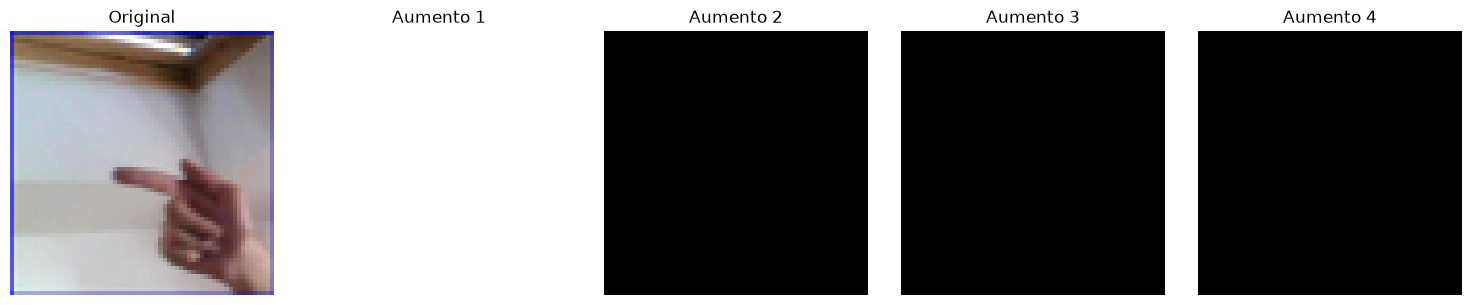

In [26]:
aumento = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(15 / 360),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='aumento_datos')

imagen_muestra = X_train[0:1]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(imagen_muestra[0])
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 5):
    aumentada = aumento(imagen_muestra, training=True).numpy()
    aumentada = np.clip(aumentada, 0.0, 1.0)
    axes[i].imshow(aumentada[0])
    axes[i].set_title(f'Aumento {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [27]:
X_train_aumentado = aumento(X_train, training=True).numpy()
X_train_aumentado = np.clip(X_train_aumentado, 0.0, 1.0)

X_train_combinado = np.concatenate([X_train, X_train_aumentado], axis=0)
y_train_combinado = np.concatenate([y_train, y_train], axis=0)

print('Forma set de entrenamiento original:', X_train.shape)
print('Forma set de entrenamiento con aumento:', X_train_combinado.shape)

Forma set de entrenamiento original: (12180, 64, 64, 3)
Forma set de entrenamiento con aumento: (24360, 64, 64, 3)


In [28]:
cnn_aumentada = construir_mejor_cnn()
cnn_aumentada.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_hparams_cnn['learning_rate']),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_cnn_aumentada = cnn_aumentada.fit(X_train_combinado, y_train_combinado,
                                              validation_data=(X_val, y_val),
                                              batch_size=mejor_hparams_cnn['batch_size'], epochs=18,
                                              callbacks=[crear_early_stop()], verbose=2)

test_loss_cnn_aumentada, test_acc_cnn_aumentada = cnn_aumentada.evaluate(X_test, y_test, verbose=0)
print(f'\n{nombre_mejor_cnn} con aumento, accuracy en prueba:', round(test_acc_cnn_aumentada, 4))
print(f'{nombre_mejor_cnn} sin aumento, accuracy en prueba:', round(test_acc_mejor_cnn, 4))

Epoch 1/18


762/762 - 18s - 24ms/step - accuracy: 0.2002 - loss: 2.7646 - val_accuracy: 0.6602 - val_loss: 1.0825


Epoch 2/18


762/762 - 17s - 22ms/step - accuracy: 0.4257 - loss: 1.9682 - val_accuracy: 0.8674 - val_loss: 0.4034


Epoch 3/18


...

Epoch 12/18


762/762 - 17s - 22ms/step - accuracy: 0.5266 - loss: 1.6530 - val_accuracy: 0.9579 - val_loss: 0.1939


Epoch 13/18


762/762 - 18s - 23ms/step - accuracy: 0.5280 - loss: 1.6533 - val_accuracy: 0.9579 - val_loss: 0.2259



CNN base con aumento, accuracy en prueba: 0.9594
CNN base sin aumento, accuracy en prueba: 0.9456


In [29]:
fc_aumentada = construir_fc()
fc_aumentada.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                       loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_fc_aumentada = fc_aumentada.fit(X_train_combinado, y_train_combinado,
                                            validation_data=(X_val, y_val),
                                            batch_size=64, epochs=18,
                                            callbacks=[crear_early_stop()], verbose=2)

test_loss_fc_aumentada, test_acc_fc_aumentada = fc_aumentada.evaluate(X_test, y_test, verbose=0)
print('\nRed totalmente conectada con aumento, accuracy en prueba:', round(test_acc_fc_aumentada, 4))
print('Red totalmente conectada sin aumento, accuracy en prueba:', round(test_acc_fc, 4))

Epoch 1/18


381/381 - 6s - 17ms/step - accuracy: 0.0483 - loss: 3.5531 - val_accuracy: 0.0709 - val_loss: 3.2886


Epoch 2/18


381/381 - 6s - 16ms/step - accuracy: 0.0628 - loss: 3.2772 - val_accuracy: 0.1034 - val_loss: 3.1105


Epoch 3/18


...

Epoch 17/18


381/381 - 5s - 14ms/step - accuracy: 0.3488 - loss: 2.1753 - val_accuracy: 0.6188 - val_loss: 1.1160


Epoch 18/18


381/381 - 6s - 16ms/step - accuracy: 0.3595 - loss: 2.1480 - val_accuracy: 0.6042 - val_loss: 1.1361



Red totalmente conectada con aumento, accuracy en prueba: 0.6345
Red totalmente conectada sin aumento, accuracy en prueba: 0.6349


In [30]:
X_train_combinado_flat = X_train_combinado.reshape(len(X_train_combinado), -1)

rf_aumentado = RandomForestClassifier(n_estimators=mejor_config_rf['n_estimators'],
                                        max_depth=mejor_config_rf['max_depth'],
                                        random_state=42, n_jobs=-1)
rf_aumentado.fit(X_train_combinado_flat, y_train_combinado)

test_acc_rf_aumentado = rf_aumentado.score(X_test_flat, y_test)
print('Random Forest con aumento, accuracy en prueba:', round(test_acc_rf_aumentado, 4))
print('Random Forest sin aumento, accuracy en prueba:', round(test_acc_rf_tuned, 4))

Random Forest con aumento, accuracy en prueba: 0.9598
Random Forest sin aumento, accuracy en prueba: 0.9598


In [31]:
comparacion_aumento = pd.DataFrame({
    'modelo': [nombre_mejor_cnn, 'Red totalmente conectada', 'Random Forest'],
    'accuracy_prueba_sin_aumento': [test_acc_mejor_cnn, test_acc_fc, test_acc_rf_tuned],
    'accuracy_prueba_con_aumento': [test_acc_cnn_aumentada, test_acc_fc_aumentada, test_acc_rf_aumentado],
})
comparacion_aumento['diferencia'] = comparacion_aumento['accuracy_prueba_con_aumento'] - comparacion_aumento['accuracy_prueba_sin_aumento']
comparacion_aumento

,modelo,accuracy_prueba_sin_aumento,accuracy_prueba_con_aumento,diferencia
0,CNN base,0.945594,0.959387,0.013793
1,Red totalmente conectada,0.634866,0.634483,-0.000383
2,Random Forest,0.959770,0.959770,0.000000


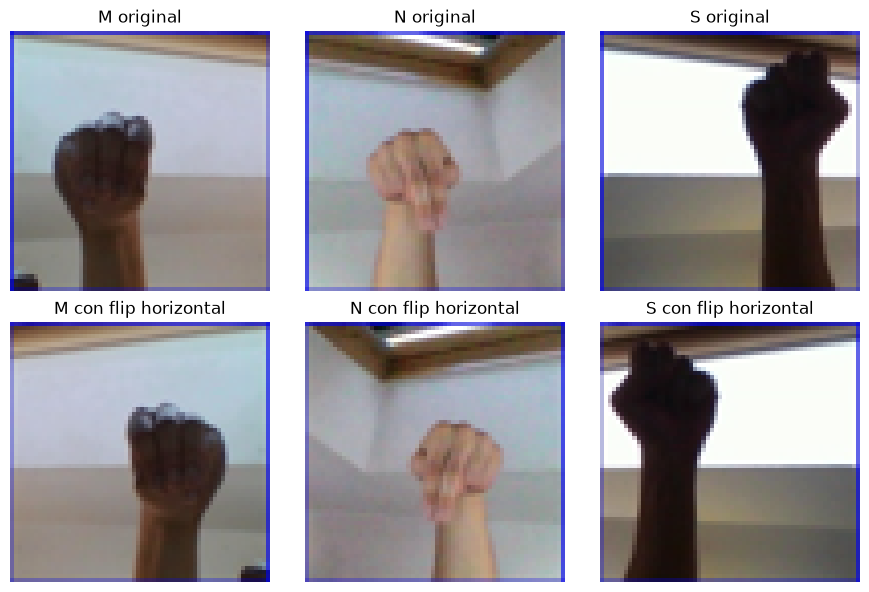

In [32]:
clases_flip_demo = ['M', 'N', 'S']
fig, axes = plt.subplots(2, len(clases_flip_demo), figsize=(9, 6))

for j, clase in enumerate(clases_flip_demo):
    idx = np.where(y_test == clase_a_indice[clase])[0][0]
    imagen = X_test[idx]
    imagen_flip = np.fliplr(imagen)

    axes[0, j].imshow(imagen)
    axes[0, j].set_title(f'{clase} original')
    axes[0, j].axis('off')

    axes[1, j].imshow(imagen_flip)
    axes[1, j].set_title(f'{clase} con flip horizontal')
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

El aumento no le hizo lo mismo a los tres modelos. La CNN base subió de 0.9456 a 0.9594 de accuracy en prueba, una mejora de casi 1.4 puntos porcentuales, la red totalmente conectada se quedó prácticamente igual, de 0.6349 a 0.6345, y el Random Forest dio exactamente el mismo 0.9598 con y sin aumento. Durante el entrenamiento de la CNN aumentada noté algo raro a primera vista, la accuracy de entrenamiento se quedó estancada alrededor de 0.52 mientras la de validación llegó hasta 0.967, pero tiene explicación, el set de entrenamiento aumentado mezcla las imágenes originales con las rotadas, corridas y con brillo alterado, que son más difíciles de clasificar, mientras que validación sigue siendo el set limpio de siempre. Que la red generalice mejor en datos limpios aunque le cueste más el set mezclado es justo el efecto que se espera de un buen aumento de datos.

Que la CNN sea la que más se beneficia tiene sentido porque es la única de las tres que aprende filtros espaciales que se pueden volver más robustos viendo la misma mano en distintas posiciones y ángulos. La red totalmente conectada no tiene esa estructura para aprovechar la variedad extra, como ya vi en la sección anterior trata cada pixel como independiente, así que darle más variaciones no le enseña invariancia, solo le agrega ruido. El Random Forest tampoco se movió, y creo que es porque ya estaba cerca de su techo con esta representación de pixeles aplanados, como noté al ajustar sus parámetros, y las reglas de corte por pixel que aprende no generalizan mejor solo por duplicar el set con versiones desplazadas de las mismas imágenes.

Sobre por qué el flip horizontal es distinto a los demás aumentos: en las imágenes de M, N y S que muestro arriba, volteadas horizontalmente, la mano sigue pareciendo una mano, pero el orden de izquierda a derecha de los dedos y el pulgar queda invertido. M y N ya son el par que más confunde la CNN base según su matriz de confusión, y ambas señas se distinguen exactamente por esa posición relativa del pulgar contra los demás dedos. Voltear la imagen no agrega una variación de cámara como sí lo hacen la rotación leve o el corrimiento de posición, cambia la geometría misma de la seña, y podría acercar visualmente una M volteada a como luce una N o una S real, metiendo una señal falsa justo en el par que el modelo ya tiene más difícil. Es distinto a rotar unos grados o mover la mano unos pixeles, eso sigue siendo la misma seña vista con un encuadre distinto, mientras que el flip cambia qué seña es.

Por esto los aumentos que sí aplico son rotación leve, hasta 15 grados, corrimiento de posición, zoom leve y variaciones de brillo y contraste, todos aumentos que simulan variabilidad de cómo se capturó la foto, no de la forma de la mano. Rotaciones más grandes que eso también las evito, porque igual que el flip podrían acercar una seña a otra dentro de los grupos M, N, S y U, V, R que identifiqué desde el análisis exploratorio. El flip horizontal y vertical quedan fuera por completo, porque ninguno de los dos representa una variación real de cómo alguien haría esa seña frente a una cámara, invierten la seña misma.

## Consolidacion de los ejercicios 4 a 7

In [33]:
resumen_final = pd.DataFrame({
    'modelo': ['CNN base', 'CNN profunda', 'Red totalmente conectada', 'Random Forest base', 'Random Forest ajustado',
               f'{nombre_mejor_cnn} con aumento', 'Red totalmente conectada con aumento', 'Random Forest con aumento'],
    'accuracy_prueba': [test_acc_base, test_acc_profunda, test_acc_fc, test_acc_rf_base, test_acc_rf_tuned,
                         test_acc_cnn_aumentada, test_acc_fc_aumentada, test_acc_rf_aumentado],
})
resumen_final = resumen_final.sort_values('accuracy_prueba', ascending=False).reset_index(drop=True)
resumen_final

,modelo,accuracy_prueba
0,Random Forest con aumento,0.959770
1,Random Forest ajustado,0.959770
2,CNN base con aumento,0.959387
3,Random Forest base,0.958238
4,CNN base,0.945594
5,CNN profunda,0.783525
6,Red totalmente conectada,0.634866
7,Red totalmente conectada con aumento,0.634483


Con los ocho modelos ordenados, el Random Forest ajustado y el mismo Random Forest con aumento quedan empatados arriba con 0.9598, la CNN base con aumento le sigue muy de cerca con 0.9594, y después viene el Random Forest base con 0.9582. Estos cuatro quedan a menos de dos puntos porcentuales entre sí. Bastante más abajo está la CNN base sin aumento con 0.9456, y ya en otro nivel quedan la CNN profunda con 0.7835 y la red totalmente conectada, que se mantuvo cerca de 0.63 con y sin aumento.

Que el Random Forest termine arriba no significa necesariamente que sea el mejor modelo para el problema real de clasificar señas. Como noté al entrenarlo, buena parte de su desempeño puede venir de aprovechar pixeles de fondo consistentes entre clases, porque las fotos de este dataset se tomaron con la misma cámara fija, algo que ya había notado en la imagen promedio por clase. Ese patrón no necesariamente se sostiene con fotos nuevas tomadas en otras condiciones, mientras que la CNN aprende filtros que reconocen la forma de la mano sin importar tanto el fondo. Para la entrega final me parece razonable seguir considerando tanto el Random Forest ajustado como la CNN base con aumento como candidatos serios, en vez de descartar la CNN solo por haber quedado unas décimas abajo en este set de prueba particular.

De los cuatro ejercicios, el patrón que más se repite es que la arquitectura o el modelo por sí solo no garantiza nada sin el ajuste de parámetros y sin pensar qué tipo de variación tiene sentido agregarle a los datos. La CNN profunda con más capas no le ganó a la más simple porque no le di suficiente entrenamiento para converger, el Random Forest mejoró más por ampliar el número de árboles que por restringir su profundidad, y el aumento de datos solo ayudó al modelo que tenía la estructura para aprovecharlo. Dejo estos resultados como base para que Ernesto pruebe con señas propias y Hugo arme la comparación final.

## Ejercicio 8: prueba con senas propias

Para ver si los dos candidatos generalizan fuera del dataset de Kaggle, cada integrante del grupo tomo fotos de su propia mano haciendo senas del alfabeto ASL, con fondo e iluminacion distintos a los del dataset original. Antes de tomar las fotos genero una hoja de referencia con imagenes reales del dataset para que cada quien sepa exactamente que forma imitar.

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

asignacion_senas = {
    'Hugo': ['A', 'B', 'C', 'D', 'M'],
    'Ernesto': ['E', 'L', 'O', 'V', 'N'],
    'Esteban': ['W', 'Y', 'F', 'K', 'S'],
}

fig, axes = plt.subplots(len(asignacion_senas), 5, figsize=(15, 9))

for i, (integrante, letras_asignadas) in enumerate(asignacion_senas.items()):
    for j, letra in enumerate(letras_asignadas):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(letra, fontsize=14)
        if j == 0:
            ax.text(-0.15, 0.5, integrante, transform=ax.transAxes, rotation=90,
                    va='center', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Referencia de senas a fotografiar, una por integrante y letra', fontsize=14)
plt.tight_layout(rect=[0.02, 0, 1, 0.96])
plt.show()


In [ ]:
from PIL import ImageOps
import re

data_propias_path = '../data_propias'

def cargar_data_propias(carpeta):
    rutas_letra = []
    rutas_integrante = []
    rutas_archivo = []
    for nombre_archivo in sorted(os.listdir(carpeta)):
        ruta_completa = os.path.join(carpeta, nombre_archivo)
        if os.path.isdir(ruta_completa):
            letra = nombre_archivo.upper()
            for sub_archivo in sorted(os.listdir(ruta_completa)):
                integrante = sub_archivo.split('_')[0].split('.')[0].lower() if '_' in sub_archivo else 'desconocido'
                rutas_letra.append(letra)
                rutas_integrante.append(integrante)
                rutas_archivo.append(os.path.join(ruta_completa, sub_archivo))
        else:
            match = re.match(r'([A-Za-z]+)_?(\w*)', os.path.splitext(nombre_archivo)[0])
            letra = match.group(1).upper()
            integrante = match.group(2).lower() if match.group(2) else 'desconocido'
            rutas_letra.append(letra)
            rutas_integrante.append(integrante)
            rutas_archivo.append(ruta_completa)

    X = np.zeros((len(rutas_archivo), 64, 64, 3), dtype=np.float32)
    y = np.zeros(len(rutas_archivo), dtype=np.int32)
    for i, ruta in enumerate(rutas_archivo):
        img = ImageOps.exif_transpose(Image.open(ruta)).convert('RGB')
        ancho, alto = img.size
        lado = min(ancho, alto)
        izquierda = (ancho - lado) // 2
        arriba = (alto - lado) // 2
        img = img.crop((izquierda, arriba, izquierda + lado, arriba + lado)).resize((64, 64))
        X[i] = np.array(img) / 255.0
        y[i] = clase_a_indice[rutas_letra[i]]
    return X, y, rutas_letra, rutas_integrante

X_propias, y_propias, letras_propias, integrantes_propias = cargar_data_propias(data_propias_path)
print('Fotos propias cargadas:', len(X_propias))
print('Integrantes:', sorted(set(integrantes_propias)))
print('Letras:', sorted(set(letras_propias)))


In [ ]:
X_propias_flat = X_propias.reshape(len(X_propias), -1)

pred_rf_propias = rf_tuned.predict(X_propias_flat)
pred_cnn_propias = cnn_aumentada.predict(X_propias, verbose=0).argmax(axis=1)

resultados_propias = pd.DataFrame({
    'integrante': integrantes_propias,
    'letra_real': letras_propias,
    'pred_rf': [clases[i] for i in pred_rf_propias],
    'pred_cnn': [clases[i] for i in pred_cnn_propias],
})
resultados_propias['acierto_rf'] = resultados_propias['letra_real'] == resultados_propias['pred_rf']
resultados_propias['acierto_cnn'] = resultados_propias['letra_real'] == resultados_propias['pred_cnn']

accuracy_rf_propias = resultados_propias['acierto_rf'].mean()
accuracy_cnn_propias = resultados_propias['acierto_cnn'].mean()

print('Random Forest ajustado, accuracy en fotos propias:', round(accuracy_rf_propias, 4),
      f"({resultados_propias['acierto_rf'].sum()}/{len(resultados_propias)})")
print('CNN base con aumento, accuracy en fotos propias:', round(accuracy_cnn_propias, 4),
      f"({resultados_propias['acierto_cnn'].sum()}/{len(resultados_propias)})")
resultados_propias


In [ ]:
print('Desglose por integrante:')
print(resultados_propias.groupby('integrante')[['acierto_rf', 'acierto_cnn']].mean())

print('\nFotos donde fallo el Random Forest:')
print(resultados_propias[~resultados_propias['acierto_rf']][['integrante', 'letra_real', 'pred_rf']])

print('\nFotos donde fallo la CNN:')
print(resultados_propias[~resultados_propias['acierto_cnn']][['integrante', 'letra_real', 'pred_cnn']])


Con las 15 fotos que tome yo mismo, el resultado es contundente: el Random Forest ajustado no acerto ninguna, 0 de 15, y la CNN base con aumento acerto solo 1 de 15, un 0.0667 de accuracy. Contra el 0.9598 y el 0.9594 que ambos modelos dieron en el set de prueba del dataset, la caida es total. Esa comparacion por si sola ya dice bastante: los modelos no generalizan a fotos tomadas en condiciones distintas a las del dataset original, aunque en el set de prueba se vean casi perfectos.

El Random Forest predijo `nothing` para las 15 fotos, sin excepcion. Al revisar la clase `nothing` del dataset me di cuenta de que son fotos de pared y techo vacios, con el mismo tono de pared y la misma luz que aparecen de fondo en mis propias fotos. En el dataset la mano llena casi todo el cuadro, mientras que en las mias, aunque ya corregi la rotacion y el encuadre cuadrado, la mano ocupa una porcion mucho menor y el resto es pared, techo y hombro. El Random Forest trabaja sobre pixeles crudos sin ningun tipo de deteccion de forma, asi que con tanto fondo de por medio termina pareciendose mas a una foto vacia que a una seña. Esto confirma la sospecha de Esteban, aunque no exactamente como el la planteo: no es que el Random Forest reconozca el fondo fijo especifico de la camara del dataset, sino que depende de que el fondo sea minimo, y en cuanto la proporcion de fondo crece se cae por completo.

La CNN con aumento tampoco se salvo, pero fallo distinto. En vez de irse a `nothing`, predijo la letra L para 13 de las 15 fotos, sin importar la seña real, y solo acerto cuando la foto real era justo una L. Ese patron es tipico de un modelo que se enfrenta a datos muy fuera de lo que vio en entrenamiento y termina cayendo en una salida por defecto, no de un modelo que este razonando la forma de la mano. El aumento de datos que aplico Esteban (rotacion, zoom, brillo, contraste) ayuda contra variaciones pequeñas, pero no prepara al modelo para un encuadre con esta cantidad de fondo extra ni para un angulo de camara tan distinto al de un dataset tomado con la mano pegada al lente.

Por ahora solo tengo mis propias fotos, las de Hugo y Esteban todavia no estan listas, asi que no puedo comparar todavia si la iluminacion, el fondo o el tono de piel de cada integrante cambian el resultado. Actualizo esta seccion en cuanto lleguen esas fotos.